In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from build_utils import get_universalization_summary, get_outcome_metrics
from source_comparison_utils import (
    regression_by_source, 
    add_effect_sizes_by_source, 
    add_zscores_by_source,
    plot_regression_by_source, 
    plot_effect_vs_sd_by_source,
    plot_zscores_by_source
)

In [2]:
### TODO ###
# Make compatible with new build_utils file, that produces one df per xp.
# Minimal changes to source_comaparison_utils file so can be used here and for xp thing (actually they should already work right?)
# Old version called df = get_summaryxxx, using one big sumamry file for all run types (we can also just call it...)

In [3]:
# Still works this way though, just using the summary csv with all run types from before...
df = pd.read_csv("../data/simulations/summary_statistics.csv")
df

,map,source,first,first_sd,last,last_sd,gap,gap_sd,average,average_sd,total,total_sd,aggregate_welfare,aggregate_welfare_sd,gap_normalized,gap_normalized_sd,gini,gini_sd,n_runs
0,10esque,line,21.00,NaN,77.00,NaN,56.00,NaN,49.0000,NaN,392.00,NaN,0.000000,NaN,0.000000,NaN,0.214286,NaN,NaN
1,10esque,1cut,21.00,NaN,77.00,NaN,56.00,NaN,49.0000,NaN,392.00,NaN,0.000000,NaN,0.000000,NaN,0.214286,NaN,NaN
2,10esque,paper_data,29.80,4.816638,108.60,5.549775,78.80,3.962323,67.0500,6.028967,536.40,48.231732,-1.875325,0.626386,0.296104,0.051459,0.222280,0.019840,5.0
3,10esque,level-1,28.58,4.664630,108.04,6.736922,79.46,5.901262,66.9500,5.129074,535.60,41.032590,-1.864935,0.532891,0.304675,0.076640,0.225047,0.017669,50.0
4,10esque,level-0,29.18,4.326897,105.66,5.783897,76.48,5.548451,64.7025,4.162507,517.62,33.300052,-1.631429,0.432468,0.265974,0.072058,0.223117,0.015735,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,yes_line_F,line,44.00,NaN,51.00,NaN,7.00,NaN,47.5000,NaN,380.00,NaN,0.000000,NaN,0.000000,NaN,0.027632,NaN,NaN
152,yes_line_F,1cut,34.00,NaN,49.00,NaN,15.00,NaN,44.5000,NaN,356.00,NaN,0.470588,NaN,0.156863,NaN,0.049157,NaN,NaN
153,yes_line_F,paper_data,26.20,0.447214,101.00,8.717798,74.80,8.871302,62.8000,2.924305,502.40,23.394444,-2.400000,0.458715,1.329412,0.173947,0.216382,0.012372,5.0
154,yes_line_F,level-1,28.44,2.829581,97.80,6.824326,69.36,6.626354,60.7000,2.274526,485.60,18.196210,-2.070588,0.356788,1.222745,0.129929,0.214166,0.013760,50.0


In [22]:
# Comparison to investigate
metric = "gini"
ref_source = "level-0"
alt_source = "level-1"

,Parameter,Value,Std Error,t-stat,p-value,Sig
0,Correlation (r),0.9943,—,—,—,—
1,Slope,0.9268,0.0191,-3.826,0.0007005,***
2,Intercept,0.0177,0.0037,4.746,6.027e-05,***
3,Mean Abs Error,0.0063,—,—,—,—
4,RMSE,0.0080,—,—,—,—
5,Max Abs Diff,0.0213,—,—,—,—
6,Range (ref),0.2133,—,—,—,—
7,N maps,29,—,—,—,—


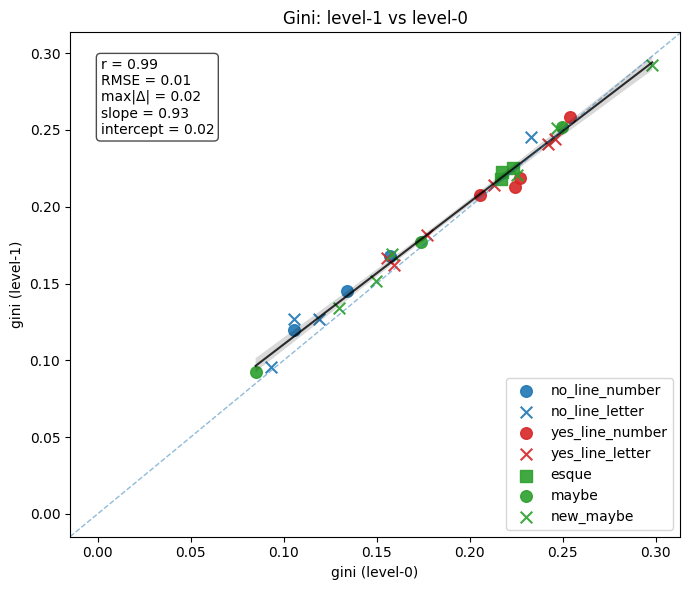

In [23]:
# Global comparison: how well does alt_source track ref_source on this metric?
summary_df, per_map_df = regression_by_source(
    df,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source
)

display(summary_df) # summary table
# per_map_df  # uncomment if you want the per-map table

fig, ax = plot_regression_by_source(
    df=df,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    title="Gini: level-1 vs level-0",
    #xlabel="My level-0 universalized aggregate welfare",
    #ylabel="My level-1 universalized aggregate welfare",
    save_path="figures/lvl1_vs_lvl0/gini.png",
)

,map,delta_aggregate_welfare_level-1_vs_level-0,d_aggregate_welfare_level-1_vs_level-0,q_aggregate_welfare_level-1_vs_level-0,relative_aggregate_welfare_level-1_vs_level-0
57,new_maybe_5,0.522453,0.228613,0.064204,0.093573
123,yes_line_A,0.086364,0.037791,0.010613,0.035547
154,yes_line_F,0.032941,0.014414,0.004048,0.01566
87,no_line_B,-0.01087,-0.004756,-0.001336,-0.0049
130,yes_line_B,-0.050312,-0.022016,-0.006183,-0.0252
33,new_maybe_1,-0.03907,-0.017096,-0.004801,-0.026258
62,new_maybe_6,-0.154583,-0.067642,-0.018997,-0.037037
72,no_line_2,-0.092857,-0.040632,-0.011411,-0.039418
51,new_maybe_4,-0.242857,-0.106268,-0.029845,-0.053434
92,no_line_C,-0.1456,-0.063711,-0.017893,-0.057009


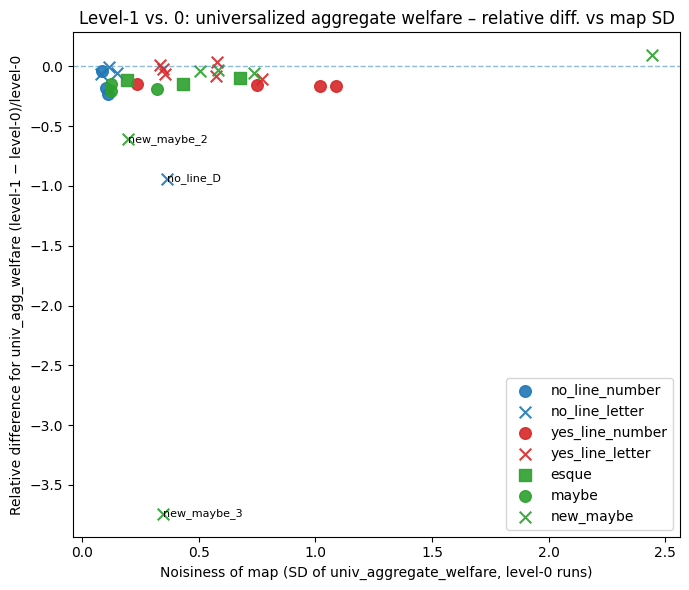

In [49]:
# Map-level effect sizes: where does alt_source differ most from ref_source?

df_eff = add_effect_sizes_by_source(
    df,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source
)

# Effect size columns
delta_col = f"delta_{metric}_{alt_source}_vs_{ref_source}"
d_col     = f"d_{metric}_{alt_source}_vs_{ref_source}"
q_col     = f"q_{metric}_{alt_source}_vs_{ref_source}"
rel_col   = f"relative_{metric}_{alt_source}_vs_{ref_source}"

cols = ["map", delta_col, d_col, q_col, rel_col]

# Sort by relative difference (large negative values at the bottom)
display(
    df_eff[df_eff["source"] == alt_source][cols]
        .sort_values(rel_col, ascending=False)
)

fig, ax = plot_effect_vs_sd_by_source(
    df=df_eff,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    effect_kind="rel",
    title="Level-1 vs. 0: universalized aggregate welfare – relative diff. vs map SD",
    xlabel=f"Noisiness of map (SD of univ_{metric}, {ref_source} runs)",
    ylabel=f"Relative difference for univ_agg_welfare ({alt_source} − {ref_source})/{ref_source}",
    label_threshold=0.5,   # only label reasonably big effects
    save_path="figures/relative_diff_SD_lvl1_vs_lvl0_univ_agg_welfare.png",
)

# Options for effect_kind: "difference", "d", "q", "relative"

,map,delta_aggregate_welfare_level-1_vs_level-0,z_aggregate_welfare_level-1_vs_level-0
57,new_maybe_5,0.522453,1.254972
123,yes_line_A,0.086364,0.791183
154,yes_line_F,0.032941,0.476335
33,new_maybe_1,-0.03907,-0.319244
87,no_line_B,-0.01087,-0.486267
18,maybe_4,-0.043256,-0.717287
130,yes_line_B,-0.050312,-0.740546
137,yes_line_C,-0.116,-0.849604
144,yes_line_D,-0.086364,-1.061656
13,9esque,-0.136667,-1.066288


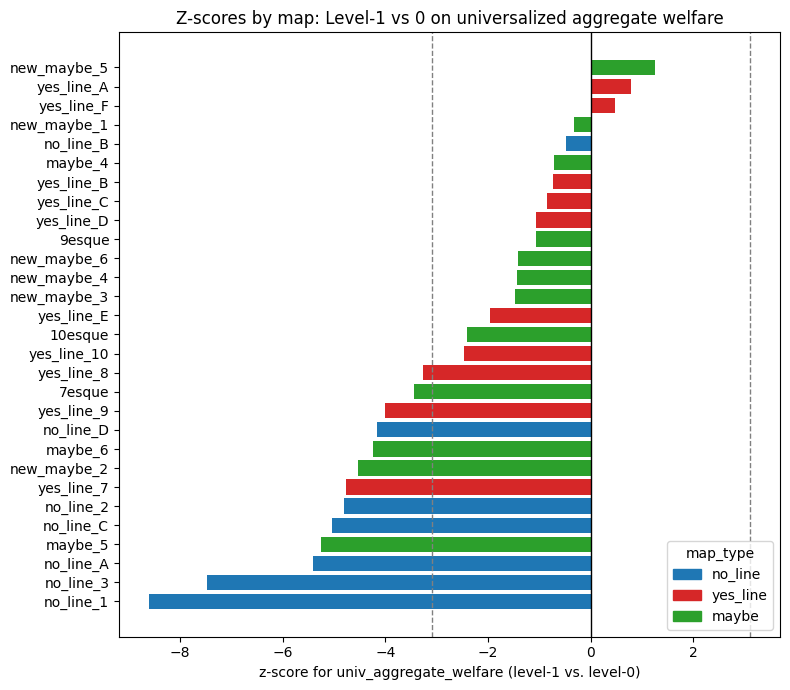

In [48]:
# Z-scores: how large are deviations in SE units?

df_z = add_zscores_by_source(
    df=df,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    se_from="both",   # set to "alt" to treat ref_source as the true distribution
)

# Z-score columns
delta_col = f"delta_{metric}_{alt_source}_vs_{ref_source}"
z_col     = f"z_{metric}_{alt_source}_vs_{ref_source}"

cols = ["map", delta_col, z_col]

# Sort by z-score (large negative values at the bottom)
display(
    df_z[df_z["source"] == alt_source][cols]
        .sort_values(z_col, ascending=False)
)

fig, ax = plot_zscores_by_source(
    df=df_z,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    threshold=3.1,    # Bonferroni threshold for 29 maps
    title="Z-scores by map: Level-1 vs 0 on universalized aggregate welfare",
    save_path=f"figures/zscores_({alt_source} − {ref_source})_univ_agg_welfare.png",
    xlabel="z-score for univ_aggregate_welfare (level-1 vs. level-0)"
)


In [7]:
df[df["map"]=="new_maybe_5"]

,map,source,first,first_sd,last,last_sd,gap,gap_sd,average,average_sd,total,total_sd,aggregate_welfare,aggregate_welfare_sd,gap_normalized,gap_normalized_sd,gini,gini_sd,n_runs
53,new_maybe_5,line,31.00,NaN,106.00,NaN,75.00,NaN,68.0000,NaN,544.00,NaN,0.000000,NaN,0.000000,NaN,0.223346,NaN,NaN
54,new_maybe_5,1cut,35.00,NaN,105.00,NaN,70.00,NaN,62.3750,NaN,499.00,NaN,0.424528,NaN,-0.047170,NaN,0.218687,NaN,NaN
55,new_maybe_5,1cut_bad,43.00,NaN,113.00,NaN,70.00,NaN,70.3750,NaN,563.00,NaN,-0.179245,NaN,-0.047170,NaN,0.193828,NaN,NaN
56,new_maybe_5,paper_data,31.80,3.033150,265.80,81.998171,234.00,82.885463,128.8000,10.768734,1030.40,86.149869,-4.588679,0.812735,1.500000,0.781938,0.317089,0.052181,5.0
57,new_maybe_5,level-1,34.64,11.600070,248.66,59.577975,214.02,60.831480,135.0575,21.729483,1080.46,173.835861,-5.060943,1.639961,1.311509,0.573882,0.292184,0.041303,50.0
58,new_maybe_5,level-0,35.88,16.206121,265.60,83.232892,229.72,84.064125,141.9800,32.390990,1135.84,259.127922,-5.583396,2.444603,1.459623,0.793058,0.298156,0.050792,50.0


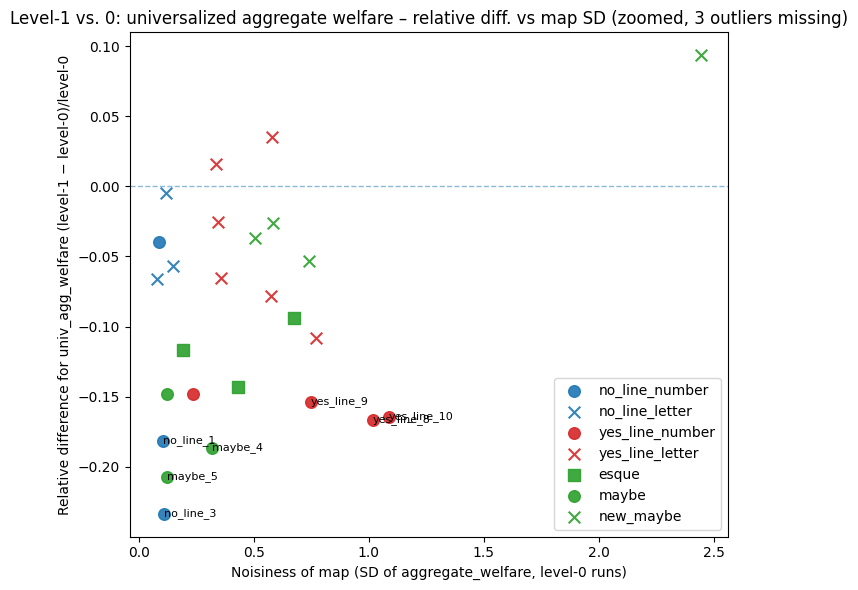

In [50]:
# Relative diff level-1 vs 0, with the 3 huge outliers removed:


eff_col = f"relative_{metric}_{alt_source}_vs_{ref_source}"
mask_ok_alt = (df_eff["source"] == alt_source) & df_eff[eff_col].between(-0.25, 0.25)
mask_other  = df_eff["source"] != alt_source
df_eff_zoom = df_eff[mask_ok_alt | mask_other].copy()

fig, ax = plot_effect_vs_sd_by_source(
    df=df_eff_zoom,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    effect_kind="relative",
    title="Level-1 vs. 0: universalized aggregate welfare – relative diff. vs map SD (zoomed, 3 outliers missing)",
    xlabel=f"Noisiness of map (SD of {metric}, {ref_source} runs)",
    ylabel=f"Relative difference for univ_agg_welfare ({alt_source} − {ref_source})/{ref_source}",
    label_threshold=0.15,   # only label reasonably big effects
    save_path="figures/relative_diff_SD_lvl1_vs_lvl0_univ_agg_welfare_ZOOMED.png",
)
#print(ax.get_ylim())
plt.show()

In [27]:
df[df["source"]=="paper_data"]

,map,source,first,first_sd,last,last_sd,gap,gap_sd,average,average_sd,total,total_sd,aggregate_welfare,aggregate_welfare_sd,gap_normalized,gap_normalized_sd,gini,gini_sd,n_runs
2,10esque,paper_data,29.8,4.816638,108.6,5.549775,78.8,3.962323,67.050,6.028967,536.4,48.231732,-1.875325,0.626386,0.296104,0.051459,0.222280,0.019840,5.0
7,7esque,paper_data,17.0,0.000000,65.8,5.449771,48.8,5.449771,39.900,1.801475,319.2,14.411801,-1.582222,0.320262,0.462222,0.121106,0.221139,0.014399,5.0
12,9esque,paper_data,17.0,1.414214,65.2,6.099180,48.2,7.155418,40.950,3.198633,327.6,25.589060,-1.658333,0.533105,0.295833,0.149071,0.221091,0.033117,5.0
17,maybe_4,paper_data,15.0,0.000000,52.2,1.788854,37.2,1.788854,27.625,0.250000,221.0,2.000000,0.255814,0.046512,0.213953,0.041601,0.247842,0.006155,5.0
22,maybe_5,paper_data,15.6,1.341641,49.2,6.140033,33.6,6.655825,30.700,1.547680,245.6,12.381438,0.868966,0.213473,-0.144828,0.114756,0.179220,0.026320,5.0
27,maybe_6,paper_data,23.0,2.915476,39.0,2.645751,16.0,3.937004,30.925,0.576899,247.4,4.615192,0.952941,0.090494,-0.235294,0.077196,0.085628,0.022640,5.0
32,new_maybe_1,paper_data,14.0,0.000000,60.4,6.387488,46.4,6.387488,35.175,1.127081,281.4,9.016651,-1.148837,0.209690,0.427907,0.148546,0.240144,0.024280,5.0
37,new_maybe_2,paper_data,16.2,0.447214,39.0,2.645751,22.8,2.774887,28.425,0.337731,227.4,2.701851,0.286364,0.061406,-0.118182,0.063066,0.140464,0.019398,5.0
44,new_maybe_3,paper_data,22.0,2.828427,55.8,2.167948,33.8,1.923538,38.250,0.918559,306.0,7.348469,-0.033898,0.124550,-0.138983,0.032602,0.151734,0.012099,5.0
50,new_maybe_4,paper_data,31.4,3.130495,116.0,13.057565,84.6,14.673105,73.900,3.675723,591.2,29.405782,-4.557143,0.525103,1.010714,0.262020,0.217259,0.024083,5.0


,map,delta_aggregate_welfare_paper_data_vs_level-0,d_aggregate_welfare_paper_data_vs_level-0,q_aggregate_welfare_paper_data_vs_level-0,relative_aggregate_welfare_paper_data_vs_level-0
96,no_line_D,0.28973,0.126779,0.035605,0.730245
32,new_maybe_1,0.33907,0.148369,0.041668,0.227884
56,new_maybe_5,0.994717,0.435264,0.12224,0.178156
107,yes_line_7,0.345778,0.151304,0.042492,0.176098
122,yes_line_A,0.270455,0.118344,0.033236,0.111319
17,maybe_4,0.023721,0.01038,0.002915,0.102204
143,yes_line_D,0.129091,0.056487,0.015864,0.098134
112,yes_line_8,0.351724,0.153906,0.043223,0.080378
136,yes_line_C,0.087556,0.038312,0.01076,0.059213
66,no_line_1,0.061333,0.026838,0.007537,0.045365


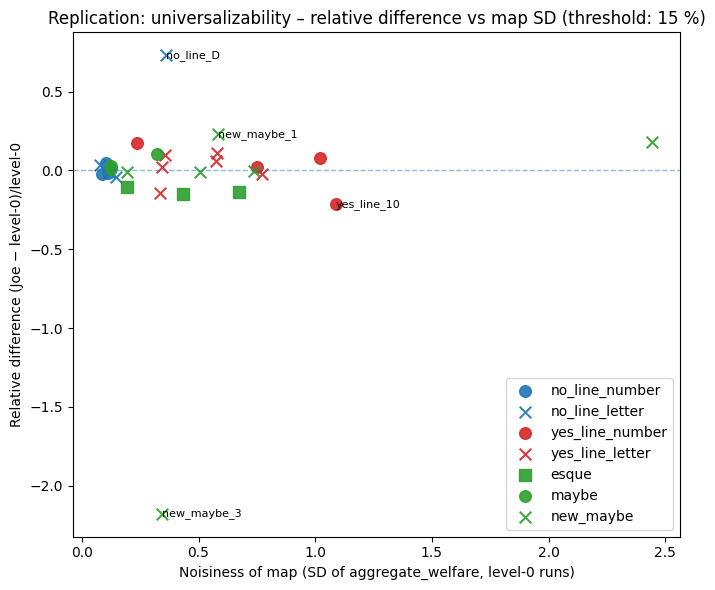

In [23]:
# relative diff joe vs level 1
# Map-level effect sizes: where does alt_source differ most from ref_source?

df_eff2 = add_effect_sizes_by_source(
    df,
    metric=metric,
    ref_source=ref_source,
    alt_source="paper_data"
)

# Effect size columns
delta_col = f"delta_{metric}_paper_data_vs_{ref_source}"
d_col     = f"d_{metric}_paper_data_vs_{ref_source}"
q_col     = f"q_{metric}_paper_data_vs_{ref_source}"
rel_col   = f"relative_{metric}_paper_data_vs_{ref_source}"

cols = ["map", delta_col, d_col, q_col, rel_col]

# Sort by relative difference (large negative values at the bottom)
display(
    df_eff2[df_eff2["source"] == "paper_data"][cols]
        .sort_values(rel_col, ascending=False)
)

fig, ax = plot_effect_vs_sd_by_source(
    df=df_eff2,
    metric=metric,
    ref_source=ref_source,
    alt_source="paper_data",
    effect_kind="relative",
    title="Replication: universalizability – relative difference vs map SD (threshold: 15 %)",
    xlabel=f"Noisiness of map (SD of {metric}, {ref_source} runs)",
    ylabel=f"Relative difference (Joe − {ref_source})/{ref_source}",
    label_threshold=0.15,   # only label reasonably big effects
    save_path="figures/replication_relative-diff_vs_sd.png",
)

# Options for effect_kind: "difference", "d", "q", "relative"

In [39]:
df_eff[df_eff["source"]=="level-1"].sort_values(f"delta_{metric}_{alt_source}_vs_{ref_source}", ascending=False)

,map,source,first,first_sd,last,last_sd,gap,gap_sd,average,average_sd,...,aggregate_welfare_sd,gap_normalized,gap_normalized_sd,gini,gini_sd,n_runs,delta_aggregate_welfare_level-1_vs_level-0,d_aggregate_welfare_level-1_vs_level-0,q_aggregate_welfare_level-1_vs_level-0,relative_aggregate_welfare_level-1_vs_level-0
57,new_maybe_5,level-1,34.64,11.600070,248.66,59.577975,214.02,60.831480,135.0575,21.729483,...,1.639961,1.311509,0.573882,0.292184,0.041303,50.0,0.522453,0.228613,0.064204,0.093573
123,yes_line_A,level-1,16.00,0.000000,74.50,12.217836,58.50,12.217836,42.8875,2.806953,...,0.510355,0.693182,0.277678,0.240940,0.026743,50.0,0.086364,0.037791,0.010613,0.035547
154,yes_line_F,level-1,28.44,2.829581,97.80,6.824326,69.36,6.626354,60.7000,2.274526,...,0.356788,1.222745,0.129929,0.214166,0.013760,50.0,0.032941,0.014414,0.004048,0.01566
87,no_line_B,level-1,16.00,0.000000,26.54,3.488816,10.54,3.488816,19.3075,0.614042,...,0.106790,-0.379565,0.075844,0.095334,0.020284,50.0,-0.01087,-0.004756,-0.001336,-0.0049
33,new_maybe_1,level-1,14.00,0.000000,66.48,11.008791,52.48,11.008791,37.2075,3.429930,...,0.638127,0.569302,0.256018,0.251258,0.033558,50.0,-0.03907,-0.017096,-0.004801,-0.026258
18,maybe_4,level-1,15.00,0.000000,53.58,5.606447,38.58,5.606447,27.9850,1.513679,...,0.281615,0.246047,0.130382,0.252005,0.023556,50.0,-0.043256,-0.018928,-0.005316,-0.186373
130,yes_line_B,level-1,41.78,3.302998,99.24,7.765859,57.46,7.083208,66.3750,2.671538,...,0.333942,0.460313,0.110675,0.161991,0.015199,50.0,-0.050312,-0.022016,-0.006183,-0.0252
144,yes_line_D,level-1,21.66,2.677266,55.80,5.402192,34.14,5.879782,37.7100,2.476734,...,0.450315,0.139545,0.133631,0.166710,0.025446,50.0,-0.086364,-0.037791,-0.010613,-0.065653
72,no_line_2,level-1,10.10,0.303046,24.64,2.327826,14.54,2.409251,16.1200,0.548048,...,0.104390,-0.320476,0.057363,0.168231,0.018128,50.0,-0.092857,-0.040632,-0.011411,-0.039418
45,new_maybe_3,level-1,20.16,2.682977,58.56,8.880522,38.40,8.969336,38.5825,2.817426,...,0.382024,-0.061017,0.152023,0.168994,0.024696,50.0,-0.107797,-0.047169,-0.013247,-3.741176


In [32]:
df_z[df_z["source"]=="level-1"].sort_values(f"z_{metric}_{alt_source}_vs_{ref_source}", ascending=False)

,map,source,first,first_sd,last,last_sd,gap,gap_sd,average,average_sd,...,gap_normalized,gap_normalized_sd,gini,gini_sd,n_runs,delta_aggregate_welfare_level-1_vs_level-0,d_aggregate_welfare_level-1_vs_level-0,q_aggregate_welfare_level-1_vs_level-0,relative_aggregate_welfare_level-1_vs_level-0,z_aggregate_welfare_level-1_vs_level-0
57,new_maybe_5,level-1,34.64,11.600070,248.66,59.577975,214.02,60.831480,135.0575,21.729483,...,1.311509,0.573882,0.292184,0.041303,50.0,0.522453,0.228613,0.064204,0.093573,1.254972
123,yes_line_A,level-1,16.00,0.000000,74.50,12.217836,58.50,12.217836,42.8875,2.806953,...,0.693182,0.277678,0.240940,0.026743,50.0,0.086364,0.037791,0.010613,0.035547,0.791183
154,yes_line_F,level-1,28.44,2.829581,97.80,6.824326,69.36,6.626354,60.7000,2.274526,...,1.222745,0.129929,0.214166,0.013760,50.0,0.032941,0.014414,0.004048,0.01566,0.476335
33,new_maybe_1,level-1,14.00,0.000000,66.48,11.008791,52.48,11.008791,37.2075,3.429930,...,0.569302,0.256018,0.251258,0.033558,50.0,-0.03907,-0.017096,-0.004801,-0.026258,-0.319244
87,no_line_B,level-1,16.00,0.000000,26.54,3.488816,10.54,3.488816,19.3075,0.614042,...,-0.379565,0.075844,0.095334,0.020284,50.0,-0.01087,-0.004756,-0.001336,-0.0049,-0.486267
18,maybe_4,level-1,15.00,0.000000,53.58,5.606447,38.58,5.606447,27.9850,1.513679,...,0.246047,0.130382,0.252005,0.023556,50.0,-0.043256,-0.018928,-0.005316,-0.186373,-0.717287
130,yes_line_B,level-1,41.78,3.302998,99.24,7.765859,57.46,7.083208,66.3750,2.671538,...,0.460313,0.110675,0.161991,0.015199,50.0,-0.050312,-0.022016,-0.006183,-0.0252,-0.740546
137,yes_line_C,level-1,12.40,1.807016,67.56,10.819785,55.16,11.174607,39.9700,4.361353,...,0.603556,0.248325,0.244158,0.029343,50.0,-0.116,-0.050759,-0.014255,-0.078449,-0.849604
144,yes_line_D,level-1,21.66,2.677266,55.80,5.402192,34.14,5.879782,37.7100,2.476734,...,0.139545,0.133631,0.166710,0.025446,50.0,-0.086364,-0.037791,-0.010613,-0.065653,-1.061656
13,9esque,level-1,17.46,3.258959,67.32,9.060883,49.86,8.710796,40.5575,3.625854,...,0.330417,0.181475,0.222896,0.027046,50.0,-0.136667,-0.059802,-0.016795,-0.093848,-1.066288


In [38]:
df[df["map"]=="no_line_D"]

,map,source,first,first_sd,last,last_sd,gap,gap_sd,average,average_sd,total,total_sd,aggregate_welfare,aggregate_welfare_sd,gap_normalized,gap_normalized_sd,gini,gini_sd,n_runs
94,no_line_D,line,9.0,NaN,37.00,NaN,28.00,NaN,23.000,NaN,184.00,NaN,0.000000,NaN,0.000000,NaN,0.228261,NaN,NaN
95,no_line_D,1cut,9.0,NaN,33.00,NaN,24.00,NaN,20.750,NaN,166.00,NaN,0.486486,NaN,-0.108108,NaN,0.206325,NaN,NaN
96,no_line_D,paper_data,9.0,0.0,33.60,8.677557,24.60,8.677557,19.825,1.336390,158.60,10.691118,0.686486,0.288949,-0.091892,0.234529,0.210139,0.036731,5.0
97,no_line_D,level-1,9.0,0.0,40.64,7.179222,31.64,7.179222,22.890,2.398533,183.12,19.188262,0.023784,0.518602,0.098378,0.194033,0.245188,0.033151,50.0
98,no_line_D,level-0,9.0,0.0,37.02,6.008463,28.02,6.008463,21.165,1.676184,169.32,13.409470,0.396757,0.362418,0.000541,0.162391,0.232788,0.030773,50.0


In [ ]:
ma